# LLM Watermarking 

## Step 1 — Install Dependencies

In [3]:
%pip install -q transformers accelerate "bitsandbytes>=0.46.1" torch "pandas==2.2.2" matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 126.2 MB/s eta 0:00:0000:010:01


## Step 2 — Set Up Path

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# Adjust this to your actual folder path in Google Drive
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks'
sys.path.insert(0, PROJECT_DIR)

# Verify
print('Package found:', os.path.isdir(os.path.join(PROJECT_DIR, 'llm_watermarking')))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Package found: True


## Step 3 — Load Model

In [20]:
from llm_watermarking.config import Config
from llm_watermarking.model_loader import load_model_and_tokenizer

cfg = Config(
    max_new_tokens=150,
    temperature=0.7,
    output_dir='outputs'
)

model, tokenizer = load_model_and_tokenizer(cfg)

Loading mistralai/Mistral-7B-Instruct-v0.2 ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 112.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 101.81 MiB is free. Including non-PyTorch memory, this process has 14.46 GiB memory in use. Of the allocated memory 14.17 GiB is allocated by PyTorch, and 174.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Step 4 — Run Pipeline

In [18]:
from llm_watermarking.prompts import PromptLoader
from llm_watermarking.pipeline import run_pipeline

# Use default prompts — or pass your own:
# loader = PromptLoader(prompts=["[INST] Your prompt here [/INST]"])
loader = PromptLoader(prompts = [
    "[INST] Describe a futuristic city in the year 2050 using vivid imagery. [/INST]",
    "[INST] Provide a step-by-step guide to baking a chocolate cake. [/INST]",
])

results, df = run_pipeline(model, tokenizer, cfg=cfg, prompt_loader=loader)
display(df)


[1/2] Generating for prompt: [INST] Describe a futuristic city in the year 2050 using viv...

[2/2] Generating for prompt: [INST] Provide a step-by-step guide to baking a chocolate ca...

--- PIPELINE COMPLETE ---
Results saved → outputs/baseline_results.jsonl


,Prompt #,Prompt Preview,Tokens,Perplexity,Dist-1,Dist-2,Avg Shannon (bits),Avg Empirical (bits),Total Shannon (bits),Total Empirical (bits)
0,1,Describe a futuristic city in the year 2050 u…,149,3.72,0.72,0.966,1.536,0.872,228.81,129.87
1,2,Provide a step-by-step guide to baking a choc…,149,1.99,0.64,0.859,0.548,0.338,81.66,50.37


## Step 5 — Visualize

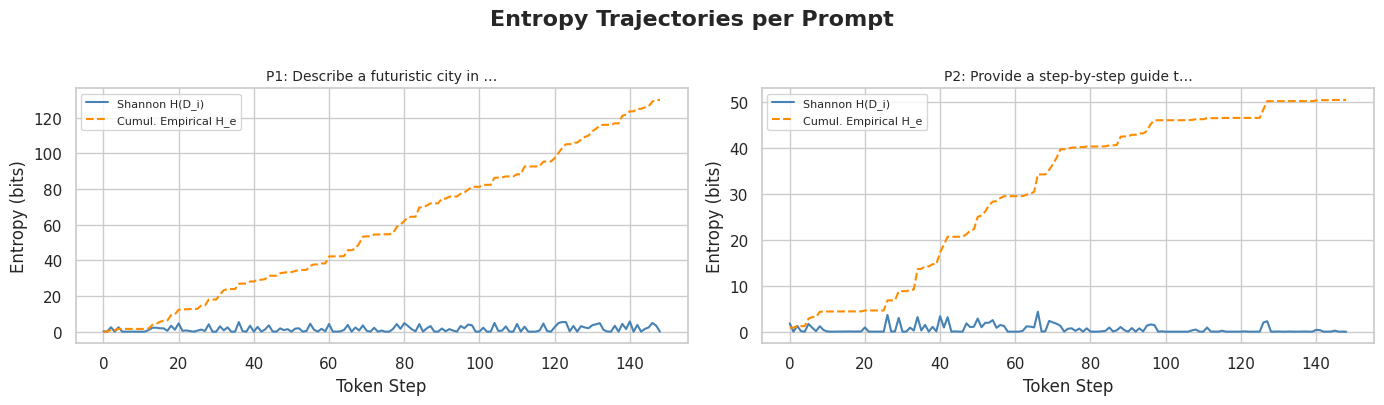

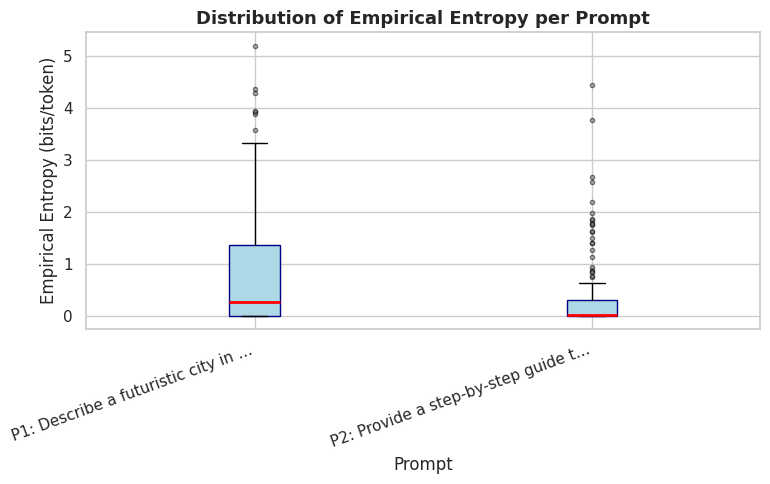

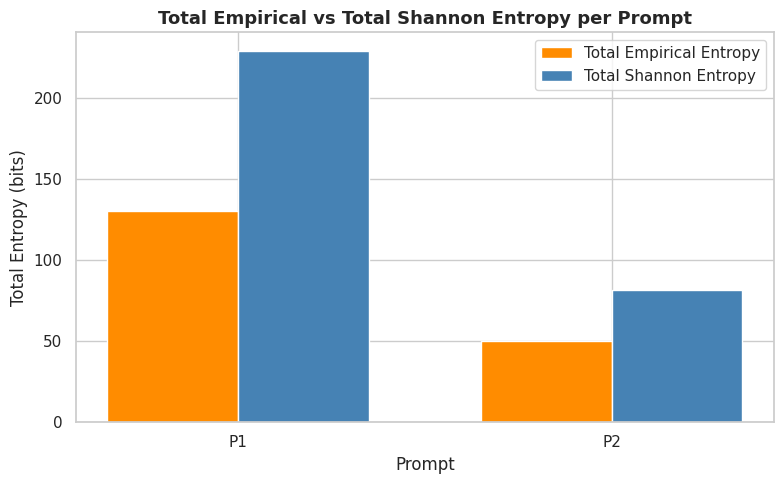

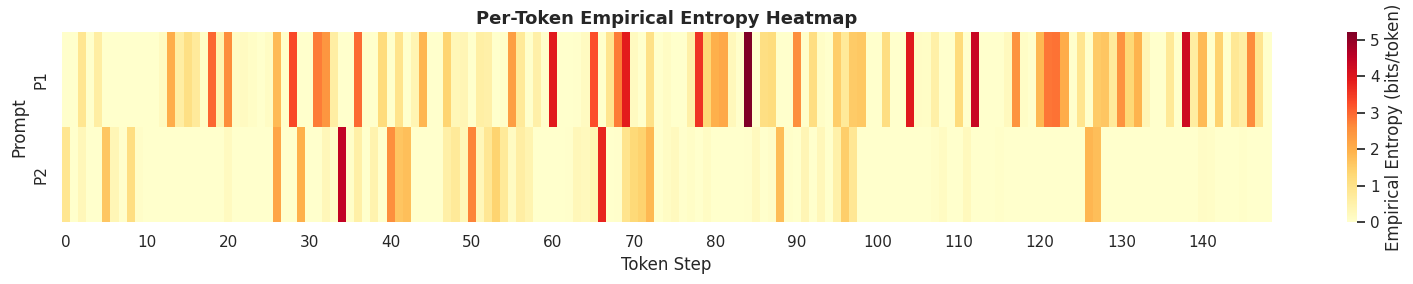

In [19]:
from llm_watermarking.visualization import plot_evaluation_metrics

plot_evaluation_metrics(results, output_dir=None)  # None = display inline

In [ ]:
import time
from llm_watermarking.generation import LLMGenerator
from llm_watermarking.evaluation import Evaluator

PROMPT = "[INST] Sum of angles in triangle is [/INST]"

generator = LLMGenerator(model, tokenizer)
evaluator = Evaluator(model, tokenizer)

gen = generator.generate_text(PROMPT, max_new_tokens=50)
ev  = evaluator.evaluate(gen)["eval"]

tokens         = gen["num_tokens"]
total_emp      = gen["total_empirical_entropy"]
avg_emp        = total_emp / tokens if tokens > 0 else 0
top_k_per_step = gen["top_k_distributions"]   # list of 5 (id, prob) per step

print("=" * 60)
print("SINGLE PROMPT EXPERIMENT")
print("=" * 60)
print(f"Response        : {gen['generated_text']}")
print(f"Tokens          : {tokens}")
print(f"Gen Time        : {gen['generation_time']}s")
print(f"Distinct-1/2    : {ev['distinct_1']:.3f} / {ev['distinct_2']:.3f}")
print(f"Total Empirical : {total_emp:.3f} bits")
print(f"Avg Empirical   : {avg_emp:.3f} bits/token")
print("=" * 60)
print("\nTop-5 Tokens at each decoding step:\n")
for step, top5 in enumerate(top_k_per_step):
    decoded = [(tokenizer.decode([tid]), f"{prob:.4f}") for tid, prob in top5]
    row = "  |  ".join(f"{tok!r:<14} {p}" for tok, p in decoded)
    print(f"Step {step+1:>3}: {row}")


SINGLE PROMPT EXPERIMENT
Response         : Paavan Parekh is a businessman and entrepreneur. He is the founder and CEO of Praveen and Paavan Enterprises, a company that deals in import and export of chemicals, textiles, and other commodities. Paavan Parekh was born on August 1, 1982, in Mumbai, India, and grew up in a business-oriented family. He received his education in Mumbai and later moved to Dubai to pursue business opportunities. Paavan's entrepreneurial journey began in 2006 when he started his first business venture in partnership with his cousin Praveen. The company quickly grew and expanded its operations to other parts of the world, including the United States
-------------------------------------------------------
Tokens generated : 149
Generation time  : 13.13s
Perplexity       : 2.45
Distinct-1       : 0.580
Distinct-2       : 0.893
Total Empirical Entropy  : 94.046 bits
Avg Empirical Entropy    : 0.631 bits/token
